#SETUP & LIBRARIES

In [2]:
!pip install PyPDF2
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install wordcloud
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.6 MB/s eta 0:00:00


In [3]:
import PyPDF2
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#UPLOAD RESUME

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Sample resume.pdf to Sample resume.pdf


In [6]:
resume_file = list(uploaded.keys())[0]

print(resume_file)

Sample resume.pdf


#EXTRACT TEXT FROM PDF

In [7]:
def extract_resume_text(pdf_path):

    text = ""

    with open(pdf_path, "rb") as file:

        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text

    return text

In [8]:
resume_text = extract_resume_text(resume_file)

print(resume_text[:1000])

JOHNSON
Chennai, Tamil Nadu, India
Email: johnson@email.com
Phone: +91 9876543210
GitHub: github.com/johnson
LinkedIn: linkedin.com/in/johnson
Career Objective
Motivated Computer Science undergraduate with a strong foundation in Java, Python, SQL, and Cloud
Computing. Passionate about developing scalable software solutions and continuously learning emerging
technologies. Seeking an entry-level Software Engineer role to contribute to innovative projects.
Technical Skills
Programming Languages: Java, Python, C, SQL
Web Technologies: HTML, CSS, JavaScript
Frameworks: Spring Boot, React
Databases: MySQL, MongoDB
Cloud & Tools: AWS, Git, GitHub, Docker, Linux
Projects
Online Banking System
Technologies: Java, JDBC, MySQL
Developed a secure banking application supporting account creation, balance inquiry, money transfer, and
transaction history.
Online Quiz Application
Technologies: HTML, CSS, JavaScript
Developed an online quiz platform with timer, score calculation, and multiple-choice que

#EXTRACT EMAIL

In [9]:
def extract_email(text):

    pattern = r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}"

    emails = re.findall(pattern,text)

    if emails:
        return emails[0]

    return "Not Found"

In [10]:
email = extract_email(resume_text)

print(email)

johnson@email.com


#EXTRACT PHONE NUMBER

In [11]:
def extract_phone(text):

    pattern = r"\+?\d[\d\s\-]{8,15}"

    phones = re.findall(pattern,text)

    if phones:
        return phones[0]

    return "Not Found"

In [12]:
phone = extract_phone(resume_text)

print(phone)

+91 9876543210



#SKILL DATABASE

In [17]:
skills_database = [

    "java",
    "python",
    "sql",
    "aws",
    "docker",
    "git",
    "github",
    "html",
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "data analysis",
    "data visualization",
    "css",
    "javascript",
    "react",
    "RESTAPI",
    "postman"
    "mongodb",
    "mysql",
    "linux",
    "spring",
    "spring boot",
    "kubernetes",
    "tensorflow",
    "data science",
    "power bi",
    "excel",
    "c",
    "c++"
]

#SKILL EXTRACTION

In [22]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills_database:

        if skill in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [23]:
resume_skills = extract_skills(resume_text)

print("Resume Skills")

for skill in resume_skills:
    print(skill)

Resume Skills
tensorflow
docker
html
mysql
github
c
react
sql
css
spring boot
data analysis
java
python
aws
linux
javascript
spring
git


In [24]:
job_description = """

Software Engineer

Required Skills

Java
SQL
AWS
Git
Docker
Spring Boot
RESTAPI
postman


Preferred

Java
SQL

"""

#JD SKILLS EXTRACTION

In [25]:
jd_skills = extract_skills(job_description)

print("JD Skills")

for skill in jd_skills:
    print(skill)

JD Skills
docker
c
spring boot
sql
java
aws
spring
git


#MATCHED & MISSING SKILLS

In [26]:
matched_skills = []

missing_skills = []

for skill in jd_skills:

    if skill in resume_skills:

        matched_skills.append(skill)

    else:

        missing_skills.append(skill)

In [27]:
print("Matched Skills")

print(matched_skills)

print()

print("Missing Skills")

print(missing_skills)

Matched Skills
['docker', 'c', 'spring boot', 'sql', 'java', 'aws', 'spring', 'git']

Missing Skills
[]


#MATCH SCORE USING NLP

In [29]:
def calculate_match_score(resume,jd):

    vectorizer = TfidfVectorizer()

    matrix = vectorizer.fit_transform(
        [resume,jd]
    )

    similarity = cosine_similarity(
        matrix[0:1],
        matrix[1:2]
    )

    return similarity[0][0] * 100

In [30]:
match_score = calculate_match_score(
    resume_text,
    job_description
)

print(round(match_score,2))

17.11


#ATS SCORE

In [31]:
def calculate_ats():

    skill_score = (
        len(matched_skills)
        /
        len(jd_skills)
    ) * 100

    ats = (

        skill_score * 0.6

        +

        match_score * 0.4

    )

    return round(ats,2)

In [32]:
ats_score = calculate_ats()

print("ATS Score:",ats_score)

ATS Score: 66.84


#COURSE RECOMMENDATION

In [33]:
course_db = {

    "docker":"Docker Masterclass",

    "git":"Git & GitHub Bootcamp",

    "spring boot":"Spring Boot Fundamentals",

    "aws":"AWS Cloud Practitioner",

    "linux":"Linux Administration",

    "kubernetes":"Kubernetes Essentials"
}

In [34]:
print("Recommended Courses")

for skill in missing_skills:

    if skill in course_db:

        print(
            skill,
            "->",
            course_db[skill]
        )

Recommended Courses


#PIE CHART

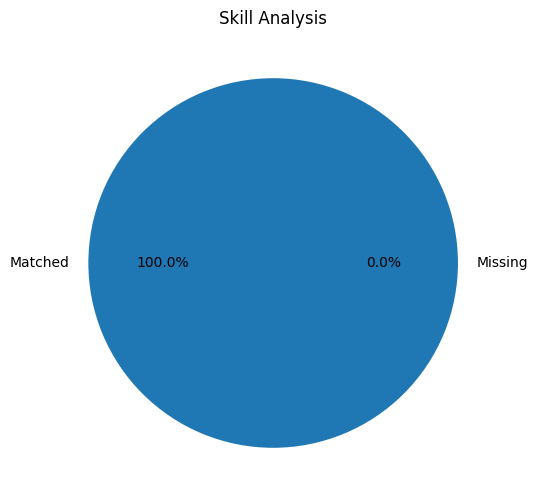

In [35]:
sizes = [

    len(matched_skills),

    len(missing_skills)

]

labels = [

    "Matched",

    "Missing"

]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Skill Analysis")

plt.show()

#WORD CLOUD

In [36]:
cloud = WordCloud(
    width=800,
    height=400
).generate(resume_text)

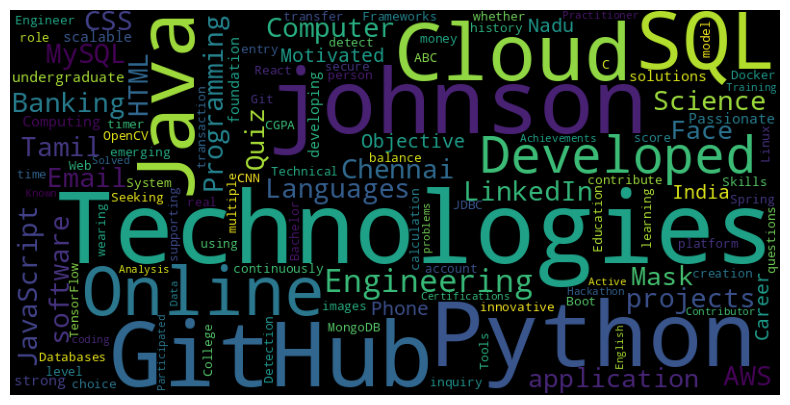

In [37]:
plt.figure(figsize=(10,5))

plt.imshow(cloud)

plt.axis("off")

plt.show()

#PDF REPORT

In [38]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)

from reportlab.lib.styles import getSampleStyleSheet

In [39]:
pdf = SimpleDocTemplate(
    "Resume_Report.pdf"
)

styles = getSampleStyleSheet()

content = []

content.append(
    Paragraph(
        "Resume Analysis Report",
        styles["Title"]
    )
)

content.append(
    Paragraph(
        f"Email: {email}",
        styles["BodyText"]
    )
)

content.append(
    Paragraph(
        f"Phone: {phone}",
        styles["BodyText"]
    )
)

content.append(
    Paragraph(
        f"ATS Score: {ats_score}",
        styles["BodyText"]
    )
)

content.append(
    Paragraph(
        f"Match Score: {round(match_score,2)}",
        styles["BodyText"]
    )
)

content.append(
    Paragraph(
        f"Missing Skills: {', '.join(missing_skills)}",
        styles["BodyText"]
    )
)

content.append(
    Spacer(1,12)
)

pdf.build(content)

print("Report Generated")

Report Generated


#DOWNLOAD REPORT

In [40]:
from google.colab import files

files.download(
    "Resume_Report.pdf"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>